# Lasers

Here we illustrate how to define and work with lasers, using the ``atomsmltr.environment.lasers`` subpackage

## Create a laser object

Defining a laser beam is quite straightforward. Here, we create a laser with a wavelength of 532nm, a waist of 30µm located at x=y=z=0, a power of 30mW, propagating along z:

In [1]:
import numpy as np
from atomsmltr.environment import GaussianLaserBeam

laser = GaussianLaserBeam(
    wavelength=532e-9,
    waist=30e-6,
    waist_position=(0, 0, 0),
    power=30e-3,
    direction=(0, 0, 1),
)

laser.print_info(show_polar=False)

───────────────────────
| Gaussian Laser Beam |
───────────────────────
. Parameters :
  ├── type : Gaussian beam
  ├── tag : satuqa
  ├── waist (m) : 3e-05
  ├── power (W) : 0.03
  ├── waist position (m) : [0 0 0]
  ├── direction type : vector
  ├── direction : [0 0 1]
  ├── unit vector : [0. 0. 1.]
  ├── unit vector phi : π × 0.0
  ├── unit vector theta : π × 0.0
  └── Rayleigh length : 0.0053 m




The propagation direction can be set using a vector, or with a couple of azimuthal & polar angles :

In [2]:
# - update the previous laser beam to make it propagate along -y
laser.direction_type = "vector"
laser.direction = (0, -1, 0)

# - set a new direction using angles
laser.direction_type = "thetaphi"
laser.direction = (np.pi, np.pi/2)  # (θ, 𝜙)
laser.print_info(show_polar=False)

───────────────────────
| Gaussian Laser Beam |
───────────────────────
. Parameters :
  ├── type : Gaussian beam
  ├── tag : satuqa
  ├── waist (m) : 3e-05
  ├── power (W) : 0.03
  ├── waist position (m) : [0 0 0]
  ├── direction type : thetaphi
  ├── direction : [3.14159265 1.57079633]
  ├── unit vector : [ 7.49879891e-33  1.22464680e-16 -1.00000000e+00]
  ├── unit vector phi : π × 0.5
  ├── unit vector theta : π × 1.0
  └── Rayleigh length : 0.0053 m




The polarization can be set using the dedicated classes.

**NOTE** see the documentation for an explanation of how the polarization is defined

In [3]:
from atomsmltr.environment import (
    Vertical,
    Horizontal,
    CircularLeft,
    CircularRight,
    Linear,
    Vector,
)

# - Horizontal
laser.polarization = Horizontal()

# - Linear
laser.polarization = Linear(angle=np.pi / 2)

# - Arbitrary
laser.polarization = Vector((1,0.5,1))
laser.print_info()

───────────────────────
| Gaussian Laser Beam |
───────────────────────
. Parameters :
  ├── type : Gaussian beam
  ├── tag : satuqa
  ├── waist (m) : 3e-05
  ├── power (W) : 0.03
  ├── waist position (m) : [0 0 0]
  ├── direction type : thetaphi
  ├── direction : [3.14159265 1.57079633]
  ├── unit vector : [ 7.49879891e-33  1.22464680e-16 -1.00000000e+00]
  ├── unit vector phi : π × 0.5
  ├── unit vector theta : π × 1.0
  └── Rayleigh length : 0.0053 m

. Polarization settings :
  ├── type : Vector
  └── vector : [0.66666667 0.33333333 0.66666667]

. Polarization vector :
  ├── coords : (0.67, 0.33, 0.67)
  ├── polar angle u : 0.27 pi
  └── azimt angle v : 0.15 pi

. Projections (amplitudes) :
  ├── vertical : 0.84-0.16j
  ├── horizontal : 0.42+0.32j
  ├── circular left : 0.37+0.18j
  └── circular right : 0.82-0.41j

. Projections (squared norm) :
  ├── vertical : 0.72
  ├── horizontal : 0.28
  ├── circular left : 0.17
  └── circular right : 0.83




## Some useful methods and properties

The ``Laser`` class comes with a lot of built-in methods, see full API documentation. Here are some useful methods to keep in mind:

In [4]:
# -- get the intensity at position (x,y,z)
laser.get_value((0,0,0))

# -- adjust the waist to reach a given intensity
target_intensity = 1e4  # W/m^2
laser.set_waist_from_I(target_intensity)

# -- adjust the power to reach a given intensity
target_intensity = 1e4  # W/m^2
laser.set_power_from_I(target_intensity)

The ``Laser`` class also handles polarization quite well, and can compute the projection of the laser polarization on the π, σ+, σ- components for a given quantization axis.

In our case, we always define the quantization axis along the local magnetic field (see documentation for more details).

In [5]:
# -- get projection of laser polarization for a given magnetic field

# laser propagation along +z, linearly polarized along x (i.e. "vertical")
laser.polarization = Vertical()
laser.direction_type = "vector"
laser.direction = (0, 0, 1)

# for a magnetic field along x, it will be purely π polarized
quantization_axis = (1, 0, 0)  # axis // x
polar = laser.get_polarization_quant_dict(quantization_axis)
display("Example 1 > B along x")
display(polar)

# for a magnetic field along z, it will be purely σ polarized
quantization_axis = (0, 0, 1)  # axis // z
polar = laser.get_polarization_quant_dict(quantization_axis)
display("Example 2 > B along z")
display(polar)


'Example 1 > B along x'

{'sigma+': np.float64(9.7632093990781e-33),
 'sigma-': np.float64(1.4916587961569202e-34),
 'pi': np.float64(0.9999999999999996)}

'Example 2 > B along z'

{'sigma+': np.float64(0.4999999999999998),
 'sigma-': np.float64(0.4999999999999998),
 'pi': np.float64(0.0)}

## Plotting

Here are some examples for laser plotting

### 2D plotting (intensity)

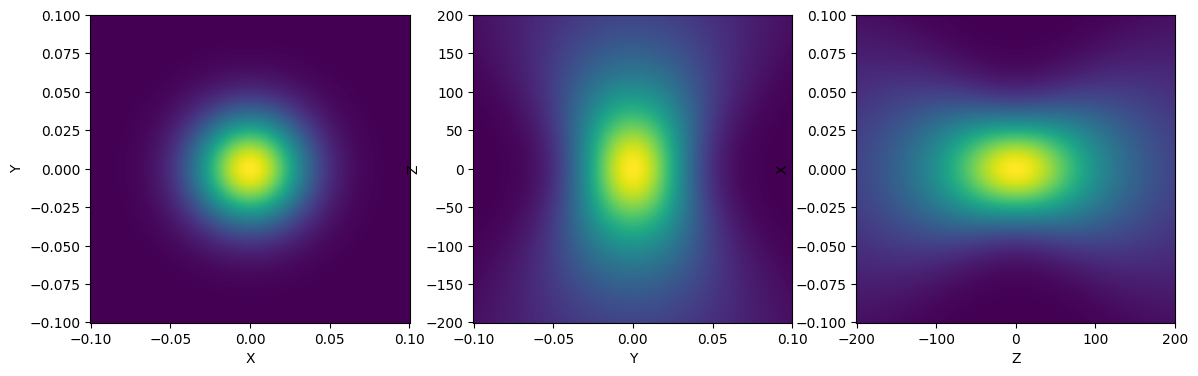

In [6]:
from atomsmltr.environment import GaussianLaserBeam
import matplotlib.pyplot as plt

# - Define the beam
beam = GaussianLaserBeam(
    wavelength=780e-9,
    waist=0.5e-3,
    power=50e-3,
    waist_position=[0, 0, 0],
    direction=[0, 0, 1],
    direction_type="vector",
)

# - plot settings
x = 1e-3
z = 2
y = 1e-3
Npoints = 500

# - plot
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
beam.plot2D((-x, x, -y, y), Npoints, ax=ax[0], plane="XY", space_scale=1e2)
beam.plot2D((-y, y, -z, z), Npoints, ax=ax[1], plane="YZ", space_scale=1e2)
beam.plot2D((-z, z, -x, x), Npoints, ax=ax[2], plane="ZX", space_scale=1e2)
plt.show()

### 3D plotting (symbolic)

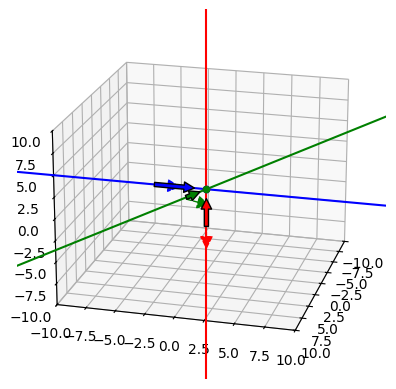

In [7]:
import matplotlib.pyplot as plt
from atomsmltr.environment.lasers import GaussianLaserBeam
from atomsmltr.utils.plotter import Axes3D
from atomsmltr.environment.lasers.polarization import (
    CircularLeft,
    CircularRight,
    Vertical,
    Vector,
)

beam1 = GaussianLaserBeam(
    wavelength=780e-9,
    waist=20e-6,
    power=50e-3,
    waist_position=[0, 0, 0],
    direction=[0, 0, 1],
    direction_type="vector",
    polarization=CircularLeft(),
)

beam2 = GaussianLaserBeam(
    wavelength=780e-9,
    waist=20e-6,
    power=50e-3,
    waist_position=[0, 0, 0],
    direction=[0, 1, 0],
    direction_type="vector",
    polarization=CircularRight(),
)

beam3 = GaussianLaserBeam(
    wavelength=780e-9,
    waist=20e-6,
    power=50e-3,
    waist_position=[0, 0, 0],
    direction=[1, 1, 1],
    direction_type="vector",
    polarization=Vector((1, 1, 1)),
)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)

beam1.plot3D(ax, color="red")
beam2.plot3D(ax, color="blue")
beam3.plot3D(ax, color="green")

ax.view_init(elev=20, azim=15, roll=0)

plt.show()